In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('car_insurance_claim.csv')

In [12]:
df.head()

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,...,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,...,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,...,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,...,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,...,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban


In [10]:
df.duplicated().sum()

0

In [9]:
df.drop_duplicates(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10301 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10301 non-null  int64  
 1   KIDSDRIV    10301 non-null  int64  
 2   BIRTH       10301 non-null  object 
 3   AGE         10294 non-null  float64
 4   HOMEKIDS    10301 non-null  int64  
 5   YOJ         9753 non-null   float64
 6   INCOME      9731 non-null   object 
 7   PARENT1     10301 non-null  object 
 8   HOME_VAL    9726 non-null   object 
 9   MSTATUS     10301 non-null  object 
 10  GENDER      10301 non-null  object 
 11  EDUCATION   10301 non-null  object 
 12  OCCUPATION  9636 non-null   object 
 13  TRAVTIME    10301 non-null  int64  
 14  CAR_USE     10301 non-null  object 
 15  BLUEBOOK    10301 non-null  object 
 16  TIF         10301 non-null  int64  
 17  CAR_TYPE    10301 non-null  object 
 18  RED_CAR     10301 non-null  object 
 19  OLDCLAIM    10301 non-null  ob

In [14]:
data_df = df.copy()


In [15]:
col_names = {
    'KIDSDRIV': 'num_young_drivers',
    'BIRTH': 'date_of_birth',
    'AGE': 'age',
    'HOMEKIDS': 'num_of_children',
    'YOJ': 'years_job_held_for',
    'INCOME': 'income',
    'PARENT1': 'single_parent',
    'HOME_VAL': 'value_of_home',
    'MSTATUS': 'married',
    'GENDER': 'gender',
    'EDUCATION': 'highest_education',
    'OCCUPATION': 'occupation',
    'TRAVTIME': 'commute_dist',
    'CAR_USE': 'type_of_use',
    'BLUEBOOK': 'vehicle_value',
    'TIF': 'policy_tenure',
    'CAR_TYPE': 'vehicle_type',
    'RED_CAR': 'red_vehicle',
    'OLDCLAIM': '5_year_total_claims_value',
    'CLM_FREQ': '5_year_num_of_claims',
    'REVOKED': 'licence_revoked',
    'MVR_PTS': 'license_points',
    'CLM_AMT': 'new_claim_value',
    'CAR_AGE': 'vehicle_age',
    'CLAIM_FLAG': 'is_claim',
    'URBANICITY': 'address_type'
}

data_df.rename(columns = col_names, inplace=True)

In [20]:
data_df.head(10)

,ID,num_young_drivers,date_of_birth,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,...,vehicle_type,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type
0,63581743,0,16MAR39,60.0,0,11.0,67349,No,0,z_No,...,Minivan,yes,4461,2,No,3,0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,91449,No,257252,z_No,...,Minivan,yes,0,0,No,0,0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,52881,No,0,z_No,...,Van,yes,0,0,No,2,0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,16039,No,124191,Yes,...,z_SUV,no,38690,2,No,3,0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,<NA>,No,306251,Yes,...,Minivan,yes,0,0,No,0,0,6.0,0,Highly Urban/ Urban
5,743146596,0,17MAY49,50.0,0,NaN,114986,No,243925,Yes,...,z_SUV,no,19217,2,Yes,3,0,17.0,0,Highly Urban/ Urban
6,871024631,0,05MAY65,34.0,1,12.0,125301,Yes,0,z_No,...,Sports Car,no,0,0,No,0,2946,7.0,1,Highly Urban/ Urban
7,792300541,0,28FEB45,54.0,0,NaN,18755,No,<NA>,Yes,...,z_SUV,no,0,0,No,0,0,1.0,0,Highly Urban/ Urban
8,7945239,1,17SEP59,40.0,1,11.0,50815,Yes,0,z_No,...,Minivan,no,3295,1,No,2,6477,1.0,1,Highly Urban/ Urban
9,3577610,0,21AUG55,44.0,2,12.0,43486,Yes,0,z_No,...,z_SUV,no,0,0,No,0,0,10.0,0,z_Highly Rural/ Rural


In [17]:
currency_cols = ['income', 'value_of_home', 'vehicle_value', '5_year_total_claims_value', 'new_claim_value']

def format_currency_data_cols(data_df, cols):
        for col in currency_cols:
            data_df[col] = data_df[col].replace('[\\$,]', '', regex=True).astype('Int64')
        return data_df

data_df = format_currency_data_cols(data_df, currency_cols)

In [23]:
cols_with_z_prefix = []

for col in data_df.columns:
    if data_df[col].dtype == 'object':
        if data_df[col].str.startswith('z_').any():
            cols_with_z_prefix.append(col)

In [24]:
cols_with_z_prefix

['married',
 'gender',
 'highest_education',
 'occupation',
 'vehicle_type',
 'address_type']

In [25]:
def drop_z_prefix_cols(data_df, cols):
    for col in cols:
        data_df[col] = data_df[col].replace('[z_]', '', regex = True)
    return data_df

data_df = drop_z_prefix_cols(data_df, cols_with_z_prefix)

In [31]:
data_df.head()

,ID,num_young_drivers,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,gender,...,vehicle_type,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type
0,63581743,0,60.0,0,11.0,67349,No,0,No,M,...,Minivan,yes,4461,2,No,3,0,18.0,0,Highly Urban/ Urban
1,132761049,0,43.0,0,11.0,91449,No,257252,No,M,...,Minivan,yes,0,0,No,0,0,1.0,0,Highly Urban/ Urban
2,921317019,0,48.0,0,11.0,52881,No,0,No,M,...,Van,yes,0,0,No,2,0,10.0,0,Highly Urban/ Urban
3,727598473,0,35.0,1,10.0,16039,No,124191,Yes,F,...,SUV,no,38690,2,No,3,0,10.0,0,Highly Urban/ Urban
4,450221861,0,51.0,0,14.0,<NA>,No,306251,Yes,M,...,Minivan,yes,0,0,No,0,0,6.0,0,Highly Urban/ Urban


In [36]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10301 entries, 0 to 10301
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   num_young_drivers          10301 non-null  int64  
 1   age                        10294 non-null  float64
 2   num_of_children            10301 non-null  int64  
 3   years_job_held_for         9753 non-null   float64
 4   income                     9731 non-null   Int64  
 5   single_parent              10301 non-null  object 
 6   value_of_home              9726 non-null   Int64  
 7   married                    10301 non-null  object 
 8   gender                     10301 non-null  object 
 9   highest_education          10301 non-null  object 
 10  occupation                 9636 non-null   object 
 11  commute_dist               10301 non-null  int64  
 12  type_of_use                10301 non-null  object 
 13  vehicle_value              10301 non-null  Int64  


In [ ]:
data_df.drop(columns=['date_of_birth', 'ID'], inplace=True)

In [37]:
mask = (data_df['new_claim_value'] > 0) & (data_df['is_claim'] == 0)
data_df[mask]

,num_young_drivers,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,gender,highest_education,...,vehicle_type,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type


<Axes: xlabel='new_claim_value', ylabel='Count'>

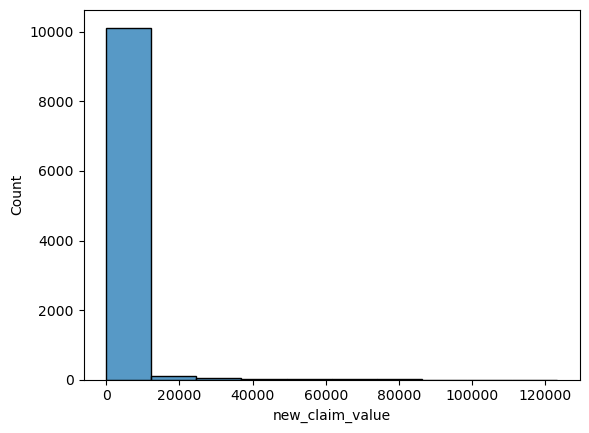

In [41]:
import seaborn as sns

sns.histplot(data_df['new_claim_value'], bins=10)

In [ ]:
# Define bins
bins = [0.0, 5000, 10_000, 15_000, 20_000, 25_000, 30_000, 35_000, 40_000, 45_000, 50_000, np.inf]
# Define bin labels
labels = np.arange(1, 12)

# Apply the bins using cut
data_df['claim_value_cat'] = pd.cut(data_df['new_claim_value'], bins = bins, labels= labels, include_lowest=True)